In [15]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [16]:
# Загрузка данных
X = pd.read_excel('X_data.xlsx')
df_y = pd.read_excel('Y_data.xlsx')

# создание бинарной целевой переменной на основе медианного значения SI
y = (df_y['SI'] > 8).astype(int)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
# Decision Tree Classifier для предсказания исходного SI > 8 на основе молекулярных дескрипторов

# Создание и обучение модели
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

clf.fit(X_train, y_train)

# Предсказывание на тестовой выборке
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Decision Tree:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Decision Tree:
              precision    recall  f1-score   support

           0       0.69      0.88      0.77       129
           1       0.57      0.30      0.39        71

    accuracy                           0.67       200
   macro avg       0.63      0.59      0.58       200
weighted avg       0.65      0.67      0.64       200

Матрица ошибок:
[[113  16]
 [ 50  21]]
Точность модели: 0.67
ROC AUC модели: 0.66


##### Вывод:

Для первичной оценки возможности разделения соединений по уровню SI > 8 была использована модель DecisionTreeClassifier. Одиночное дерево решений показало умеренное качество классификации (Accuracy ≈ 0.67, ROC-AUC ≈ 0.66). Модель значительно лучше распознавала класс 0 (recall ≈ 0.88), чем класс 1 (recall ≈ 0.30), что указывает на выраженную сложность выявления соединений с высокими значениями SI. Матрица ошибок показывает большое количество ложноотрицательных предсказаний для класса 1.


In [18]:
# Настройка гиперпараметров для Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

# Вывод лучших параметров и результатов кросс-валидации
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

# Получение лучшей модели
best_rf = search.best_estimator_

# Предсказывание на тестовой выборке
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Random Forest:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}
Best CV ROC-AUC: 0.7470302684180468
Отчет о классификации Random Forest:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81       129
           1       0.68      0.45      0.54        71

    accuracy                           0.73       200
   macro avg       0.71      0.67      0.68       200
weighted avg       0.72      0.73      0.71       200

Матрица ошибок:
[[114  15]
 [ 39  32]]
Точность модели: 0.73
ROC AUC модели: 0.73


##### Вывод:
Для повышения устойчивости модели и уменьшения переобучения был использован RandomForestClassifier. Подбор гиперпараметров осуществлялся с помощью RandomizedSearchCV и кросс-валидации (cv=5) по метрике ROC-AUC.

По сравнению с одиночным деревом решений RandomForestClassifier продемонстрировал более высокое качество классификации (Accuracy ≈ 0.73, ROC-AUC ≈ 0.73) и обеспечил более устойчивое разделение классов. Использование ансамблевого подхода позволило уменьшить количество ошибок классификации и повысить качество распознавания соединений с SI > 8 (recall ≈ 0.45 против 0.30 у одиночного дерева решений), хотя задача классификации по-прежнему остаётся достаточно сложной.

Высокое значение Best CV ROC-AUC ≈ 0.75, полученное при кросс-валидации, свидетельствует о наличии устойчивых закономерностей между молекулярными дескрипторами и высокой селективностью соединений. 

Полученные результаты позволяют предположить, что задача классификации соединений с SI > 8 содержит более выраженные закономерности по сравнению с классификацией относительно медианного значения SI, однако по-прежнему характеризуется высоким уровнем сложности и частичным перекрытием классов в пространстве молекулярных дескрипторов.


<Axes: title={'center': 'Важность признаков после обучения случайного леса'}, ylabel='Feature'>

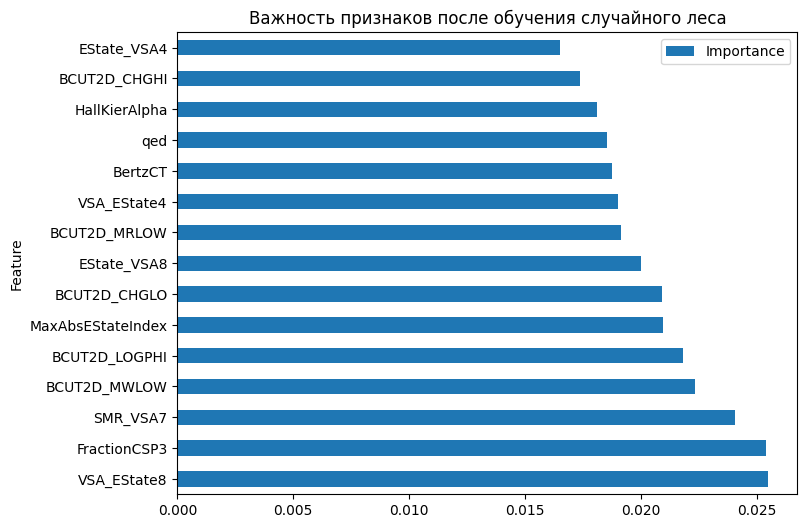

In [19]:
# визуализация важности признаков после обучения случайного леса
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения случайного леса'
)

Анализ важности признаков RandomForestClassifier для классификации соединений с SI > 8 показал, что наибольший вклад в разделение классов вносят дескрипторы, характеризующие электронные свойства, топологию и физико-химические характеристики молекул.

Среди наиболее значимых признаков модель выделила VSA_EState8, FractionCSP3, SMR_VSA7, BCUT2D_MWLOW, BCUT2D_LOGPHI, MaxAbsEStateIndex и BCUT2D_CHGLO. Это указывает на важную роль пространственной структуры молекулы, распределения электронной плотности, липофильности

In [20]:
# Логистическая регрессия для предсказания исходного SI> 8 на основе молекулярных дескрипторов
# параметры модели: L1-регуляризация, solver='liblinear', max_iter=10000, random_state=42

model_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=10000,
    random_state=42
)

model_l1.fit(X_train, y_train)

# Предсказывание на тестовой выборке
y_pred = model_l1.predict(X_test)
y_prob = model_l1.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Logistic Regression с L1-регуляризацией:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Logistic Regression с L1-регуляризацией:
              precision    recall  f1-score   support

           0       0.75      0.78      0.76       129
           1       0.57      0.54      0.55        71

    accuracy                           0.69       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.69      0.69      0.69       200

Матрица ошибок:
[[100  29]
 [ 33  38]]
Точность модели: 0.69
ROC AUC модели: 0.71


In [21]:
# Логистическая регрессия для предсказания исходного SI> 8 на основе молекулярных дескрипторов
# параметры модели: L2-регуляризация, solver='liblinear', max_iter=50000, random_state=42

# cоздание и обучение модели
model_l2 = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    max_iter=50000,
    random_state=42
)

model_l2.fit(X_train, y_train)

# предсказывание на тестовой выборке
y_pred = model_l2.predict(X_test)
y_prob = model_l2.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Logistic Regression с L2-регуляризацией:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Logistic Regression с L2-регуляризацией:
              precision    recall  f1-score   support

           0       0.65      1.00      0.78       129
           1       0.00      0.00      0.00        71

    accuracy                           0.65       200
   macro avg       0.32      0.50      0.39       200
weighted avg       0.42      0.65      0.51       200

Матрица ошибок:
[[129   0]
 [ 71   0]]
Точность модели: 0.65
ROC AUC модели: 0.59


c:\Users\Ekaterina\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ekaterina\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ekaterina\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

##### Вывод:

Модель LogisticRegression с L1-регуляризацией показала более высокое качество классификации соединений с SI > 8 (Accuracy ≈ 0.69, ROC-AUC ≈ 0.71) по сравнению с моделью с L2-регуляризацией. Использование L1-регуляризации позволило уменьшить влияние мультиколлинеарности и автоматически выполнить отбор наиболее информативных молекулярных дескрипторов, что особенно важно при работе с высокоразмерными QSAR-данными. 

В отличие от L1-регуляризации, модель с L2-регуляризацией показала крайне низкое качество классификации и фактически предсказывала только один класс (SI ≤ 8). Это привело к невозможности корректного вычисления части метрик классификации и появлению предупреждений UndefinedMetricWarning. 

Полученные результаты свидетельствуют о том, что для задачи классификации соединений с SI > 8 отбор признаков играет важную роль, а использование L1-регуляризации позволяет повысить устойчивость линейных моделей в условиях большого количества коррелированных молекулярных дескрипторов. 

Несмотря на улучшение качества по сравнению с L2-регуляризацией, линейные модели классификации всё же уступили ансамблевым методам (RandomForestClassifier) по качеству разделения классов, что может указывать на наличие сложных нелинейных зависимостей между молекулярными дескрипторами и высокой селективностью соединений.

In [22]:
# CatBoost Classifier для предсказания исходного SI > 8 на основе молекулярных дескрипторов

# Создание и обучение модели
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

# Предсказывание на тестовой выборке
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации CatBoost:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации CatBoost:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74       129
           1       0.54      0.54      0.54        71

    accuracy                           0.67       200
   macro avg       0.64      0.64      0.64       200
weighted avg       0.67      0.67      0.67       200

Матрица ошибок:
[[96 33]
 [33 38]]
Точность модели: 0.67
ROC AUC модели: 0.70


##### Вывод:
Модель CatBoostClassifier показала умеренное качество классификации соединений с SI > 8 (Accuracy ≈ 0.67, ROC-AUC ≈ 0.70) и обеспечила более сбалансированное распознавание классов по сравнению с одиночным деревом решений.

По сравнению с RandomForestClassifier модель CatBoostClassifier не продемонстрировала существенного улучшения качества классификации, однако сохранила сопоставимый уровень разделения классов.

Матрица ошибок показывает, что модель испытывает сложности с распознаванием соединений с высокими значениями SI (recall ≈ 0.54 для класса 1), что может указывать на частичное перекрытие классов в пространстве молекулярных дескрипторов.

Полученные результаты свидетельствуют о том, что даже boosting-модели сталкиваются с ограничениями при решении задачи классификации соединений с высокой селективностью (SI > 8), поскольку данная характеристика зависит одновременно от биологической активности и токсичности соединений. 

Несмотря на умеренное качество классификации, модель CatBoostClassifier подтверждает наличие определённых нелинейных закономерностей между молекулярными дескрипторами и высокой селективностью соединений.


<Axes: title={'center': 'Важность признаков после обучения CatBoost'}, ylabel='Feature'>

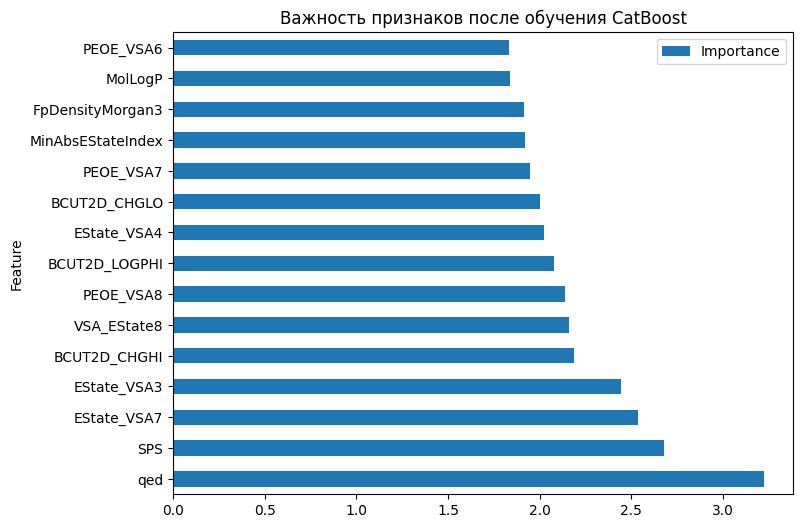

In [23]:
# визуализация важности признаков после обучения CatBoost
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения CatBoost'
)

Анализ важности признаков CatBoostClassifier для классификации соединений с SI > 8 показал, что наибольший вклад в разделение классов вносят дескрипторы, характеризующие электронные свойства, липофильность, распределение зарядов и топологические особенности молекул. 

Среди наиболее значимых признаков модель выделила qed, SPS, EState_VSA7, EState_VSA3, BCUT2D_CHGHI, VSA_EState8 и PEOE_VSA8. Это указывает на важную роль drug-likeness характеристик, пространственной структуры молекулы, распределения электронной плотности и поверхностных свойств в определении высокой селективности соединений (SI > 8).

Высокая важность дескрипторов семейств EState_VSA, PEOE_VSA и BCUT2D также свидетельствует о значительном влиянии электронных и физико-химических характеристик молекул на способность соединений сочетать высокую биологическую активность с относительно низкой токсичностью.

Полученные результаты хорошо согласуются с выводами RandomForestClassifier и подтверждают, что высокая селективность соединений определяется сложной совокупностью электронных, топологических и структурных свойств молекулы.

При этом умеренное качество классификации даже для boosting-модели CatBoostClassifier указывает на высокую сложность задачи прогнозирования соединений с SI > 8 и вероятное влияние дополнительных факторов, не полностью описываемых используемыми молекулярными дескрипторами. 

In [24]:
# SVM Classifier  для предсказания исходного SI > 8 на основе молекулярных дескрипторов

# стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание и обучение модели
model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = model.predict(X_test)
y_prob = model.decision_function(X_test)

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации SVM:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации SVM:
              precision    recall  f1-score   support

           0       0.75      0.86      0.80       129
           1       0.65      0.48      0.55        71

    accuracy                           0.72       200
   macro avg       0.70      0.67      0.68       200
weighted avg       0.72      0.72      0.71       200

Матрица ошибок:
[[111  18]
 [ 37  34]]
Точность модели: 0.72
ROC AUC модели: 0.75


In [25]:
# Настройка гиперпараметров для SVM Classifier с использованием GridSearchCV

# Создание пайплайна для стандартизации данных и обучения модели SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
])

# Определение сетки гиперпараметров для поиска
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.1, 0.01, 0.001]
}

# Настройка GridSearchCV для поиска лучших гиперпараметров
grid = GridSearchCV(
    pipe,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Обучение модели с использованием GridSearchCV
grid.fit(X_train, y_train)

# Вывод лучших параметров и результатов кросс-валидации
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

# Получение лучшей модели
best_svm = grid.best_estimator_

# Предсказывание на тестовой выборке с использованием лучшей модели
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации SVM:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'svc__C': 1, 'svc__gamma': 'scale'}
Best CV ROC-AUC: 0.7332944249067367
Отчет о классификации SVM:
              precision    recall  f1-score   support

           0       0.75      0.86      0.80       129
           1       0.65      0.48      0.55        71

    accuracy                           0.72       200
   macro avg       0.70      0.67      0.68       200
weighted avg       0.72      0.72      0.71       200

Матрица ошибок:
[[111  18]
 [ 37  34]]
Точность модели: 0.72
ROC AUC модели: 0.75


Для моделирования нелинейных зависимостей между молекулярными дескрипторами и принадлежностью соединений к различным классам была использована модель SVM (Support Vector Machine) с RBF-ядром. Поскольку метод опорных векторов чувствителен к масштабу признаков, перед обучением модели была выполнена стандартизация данных. 

Базовая модель SVM показала наилучшее качество классификации соединений с SI > 8 среди исследованных моделей (Accuracy ≈ 0.72, ROC-AUC ≈ 0.75). Полученные результаты свидетельствуют о способности SVM эффективно выявлять сложные нелинейные зависимости между молекулярными дескрипторами и высокой селективностью соединений.

Модель обеспечила достаточно устойчивое разделение классов и показала высокое качество распознавания класса 0 (recall ≈ 0.86). При этом качество распознавания соединений с высокими значениями SI (class 1) осталось умеренным (recall ≈ 0.48), что указывает на сложность выявления высокоселективных соединений по молекулярным дескрипторам.

Подбор гиперпараметров с использованием GridSearchCV не привёл к существенному изменению качества модели, поскольку оптимальными оказались параметры, близкие к исходным (C = 1, gamma = scale). Это может свидетельствовать о хорошей первоначальной настройке модели для данной QSAR-задачи.

Более высокое значение ROC-AUC по сравнению с большинством других моделей указывает на хорошую способность SVM ранжировать соединения по вероятности принадлежности к классу соединений с высокой селективностью (SI > 8). Полученные результаты подтверждают эффективность метода главных компонент для анализа высокоразмерных и сложных QSAR-данных, особенно в задачах с менее выраженными линейными закономерностями, таких как классификация SI.

##### Вывод:

В ходе работы были исследованы различные подходы к классификации соединений с высокой селективностью (SI > 8) на основе молекулярных дескрипторов. Были рассмотрены линейные и нелинейные модели машинного обучения, включая LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, CatBoostClassifier и SVM.

Одиночное дерево решений показало умеренное качество классификации (Accuracy ≈ 0.67, ROC-AUC ≈ 0.66) и продемонстрировало сложности с распознаванием соединений с высокими значениями SI.

Использование ансамблевого метода RandomForestClassifier позволило повысить качество классификации (Accuracy ≈ 0.73, ROC-AUC ≈ 0.73) и улучшить устойчивость модели по сравнению с одиночным деревом решений. Ансамблевый подход позволил более эффективно выявлять нелинейные зависимости между молекулярными дескрипторами и высокой селективностью соединений.

Линейные модели на основе логистической регрессии показали умеренное качество классификации. Использование L1-регуляризации обеспечило более устойчивые результаты (ROC-AUC ≈ 0.71) по сравнению с L2-регуляризацией, которая продемонстрировала деградацию качества и фактически предсказывала только один класс.

Модель CatBoostClassifier также показала умеренное качество классификации (Accuracy ≈ 0.67, ROC-AUC ≈ 0.70), однако не продемонстрировала существенного улучшения по сравнению с RandomForestClassifier.

Наилучшее качество классификации среди исследованных моделей показал SVM с RBF-ядром (Accuracy ≈ 0.72, ROC-AUC ≈ 0.75). Полученные результаты подтверждают высокую эффективность kernel-методов для выявления сложных нелинейных закономерностей в высокоразмерных QSAR-данных.

Анализ важности признаков показал, что наибольший вклад в классификацию соединений с SI > 8 вносят дескрипторы, характеризующие электронные свойства, распределение зарядов, топологические особенности, липофильность и пространственную структуру молекул. Наиболее значимыми оказались дескрипторы семейств BCUT2D, EState_VSA, PEOE_VSA, а также показатели qed, FractionCSP3 и MolLogP.

